📷 Starting camera for 25 seconds... Press Ctrl+C to quit early.
🔍 ORB matched coordinates (top 10): [(457, 230), (458, 231), (531, 219), (182, 271), (533, 215), (532, 214), (415, 338), (243, 125), (158, 298), (531, 218)]

0: 480x640 3 persons, 1 potted plant, 1 tv, 1 vase, 164.5ms
Speed: 7.0ms preprocess, 164.5ms inference, 12.8ms postprocess per image at shape (1, 3, 480, 640)
🪴 Potted plant coordinates: (454, 168), (628, 431)


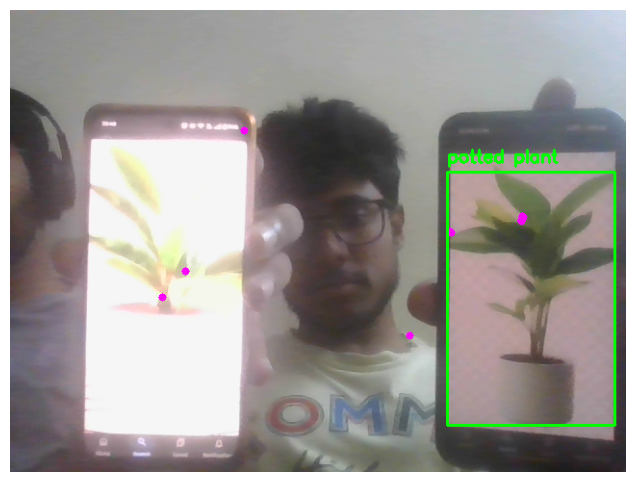

🔍 ORB matched coordinates (top 10): [(444, 128), (537, 105), (428, 414), (409, 313), (236, 121), (410, 313), (410, 313), (259, 221), (247, 128), (403, 201)]

0: 480x640 3 persons, 1 chair, 1 tv, 119.1ms
Speed: 2.9ms preprocess, 119.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
🔍 ORB matched coordinates (top 10): [(527, 96), (404, 146), (430, 269), (265, 223), (402, 291), (171, 311), (419, 340), (415, 348), (250, 146), (403, 202)]

0: 480x640 4 persons, 1 tv, 107.9ms
Speed: 2.2ms preprocess, 107.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
🔍 ORB matched coordinates (top 10): [(412, 349), (253, 131), (431, 348), (408, 311), (527, 97), (172, 312), (433, 121), (432, 122), (306, 94), (340, 247)]

0: 480x640 3 persons, 1 tv, 111.3ms
Speed: 4.2ms preprocess, 111.3ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
🔍 ORB matched coordinates (top 10): [(404, 146), (90, 148), (412, 346), (530, 97), (265, 223), (433, 273), (246, 134),

In [ ]:
import cv2
from ultralytics import YOLO
import time
import os
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # or "yolov8s.pt"

# Open webcam
cap = cv2.VideoCapture(0)

# Target class
target_class = "potted plant"

# Reference image path
ref_img_path = r'C:\Users\91939\OneDrive\Desktop\python\orb_matcher\reference.jpg'
if not os.path.exists(ref_img_path):
    print("❌ Reference image not found.")
    exit()

ref_img = cv2.imread(ref_img_path, cv2.IMREAD_GRAYSCALE)
if ref_img is None:
    print("❌ Error loading reference image.")
    exit()

# ORB setup
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(ref_img, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Set up matplotlib for live display
plt.ion()  # Interactive mode on
fig, ax = plt.subplots(figsize=(10, 6))

start_time = time.time()
print("📷 Starting camera for 25 seconds... Press Ctrl+C to quit early.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to grab frame.")
        break

    # Copy for annotation
    annotated_frame = frame.copy()

    # ORB matching
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = orb.detectAndCompute(gray_frame, None)

    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        orb_coords = [(int(kp2[m.trainIdx].pt[0]), int(kp2[m.trainIdx].pt[1])) for m in matches[:10]]
        print(f"🔍 ORB matched coordinates (top 10): {orb_coords}")
        # Draw ORB points
        for (x, y) in orb_coords:
            cv2.circle(annotated_frame, (x, y), 4, (255, 0, 255), -1)

    # YOLO detection
    results = model(frame)
    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            if cls_name == "potted plant":
                print(f"🪴 Potted plant coordinates: ({x1}, {y1}), ({x2}, {y2})")
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(annotated_frame, cls_name, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            elif "plant" in cls_name.lower():
                print(f"🌱 Other plant [{cls_name}] coordinates: ({x1}, {y1}), ({x2}, {y2})")
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 200, 255), 2)
                cv2.putText(annotated_frame, cls_name, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)

    # Convert to RGB and display with matplotlib
    annotated_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    ax.clear()
    ax.imshow(annotated_rgb)
    ax.axis('off')
    plt.pause(0.001)  # Allow update

    # Stop after 25 seconds
    if time.time() - start_time > 25:
        print("⏱️ 25 seconds elapsed. Stopping.")
        break

# Cleanup
cap.release()
plt.ioff()
plt.close()

📷 Starting camera for 25 seconds... Press Ctrl+C to quit early.
🔍 ORB matched coordinates (top 10): [(342, 412), (421, 364), (406, 364), (223, 265), (221, 329), (260, 256), (290, 349), (376, 54), (210, 385), (207, 277)]

0: 480x640 2 persons, 1 cat, 2 potted plants, 136.6ms
Speed: 3.5ms preprocess, 136.6ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
✅ 2 plant(s) detected.
🌿 Plant #1 [potted plant] @ (203,249) → (282,392) with 26 ORB matches
🌿 Plant #2 [potted plant] @ (270,306) → (425,479) with 16 ORB matches


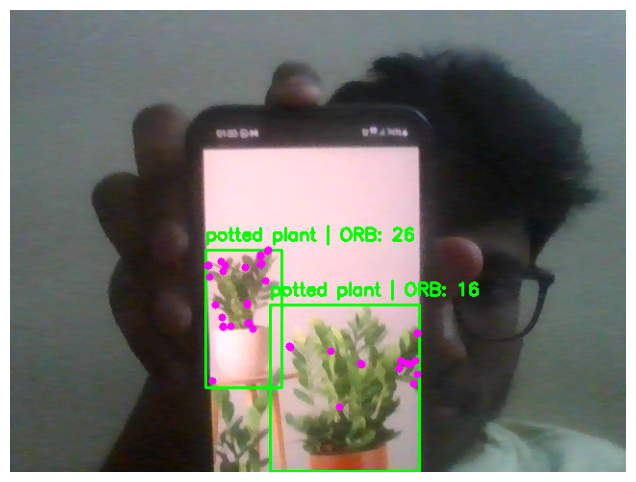

🔍 ORB matched coordinates (top 10): [(397, 351), (256, 249), (329, 402), (192, 267), (410, 377), (201, 258), (277, 339), (328, 397), (409, 368), (409, 352)]

0: 480x640 3 persons, 1 cat, 2 potted plants, 1 vase, 195.8ms
Speed: 2.6ms preprocess, 195.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
✅ 2 plant(s) detected.
🌿 Plant #1 [potted plant] @ (189,238) → (267,379) with 24 ORB matches
🌿 Plant #2 [potted plant] @ (264,295) → (413,479) with 20 ORB matches
🔍 ORB matched coordinates (top 10): [(377, 116), (179, 238), (174, 248), (172, 248), (224, 226), (180, 352), (379, 116), (181, 238), (224, 226), (168, 121)]

0: 480x640 2 persons, 1 cat, 2 potted plants, 1 vase, 105.2ms
Speed: 1.7ms preprocess, 105.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
✅ 2 plant(s) detected.
🌿 Plant #1 [potted plant] @ (170,219) → (247,359) with 21 ORB matches
🌿 Plant #2 [potted plant] @ (243,274) → (390,479) with 22 ORB matches
🔍 ORB matched coordinates (top 10): [(

In [ ]:
import cv2
from ultralytics import YOLO
import time
import os
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Open webcam
cap = cv2.VideoCapture(0)

# Reference image path
ref_img_path = r'C:\Users\91939\OneDrive\Desktop\python\orb_matcher\reference.jpg'
if not os.path.exists(ref_img_path):
    print("❌ Reference image not found.")
    exit()

ref_img = cv2.imread(ref_img_path, cv2.IMREAD_GRAYSCALE)
if ref_img is None:
    print("❌ Error loading reference image.")
    exit()

# ORB setup
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(ref_img, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Matplotlib setup
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))

start_time = time.time()
print("📷 Starting camera for 25 seconds... Press Ctrl+C to quit early.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to grab frame.")
        break

    annotated_frame = frame.copy()
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ORB keypoint matching
    kp2, des2 = orb.detectAndCompute(gray_frame, None)
    orb_coords = []

    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        orb_coords = [(int(kp2[m.trainIdx].pt[0]), int(kp2[m.trainIdx].pt[1])) for m in matches[:50]]
        print(f"🔍 ORB matched coordinates (top 10): {orb_coords[:10]}")

    # YOLO detection
    results = model(frame)
    plant_boxes = []

    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            if "plant" in cls_name.lower():
                plant_boxes.append(((x1, y1, x2, y2), cls_name))

    if not plant_boxes:
        print("❌ No plants detected in this frame.")
    else:
        print(f"✅ {len(plant_boxes)} plant(s) detected.")

    # Annotate each plant
    for idx, ((x1, y1, x2, y2), cls_name) in enumerate(plant_boxes):
        # ORB points inside box
        local_orb_pts = [(x, y) for (x, y) in orb_coords if x1 <= x <= x2 and y1 <= y <= y2]
        print(f"🌿 Plant #{idx+1} [{cls_name}] @ ({x1},{y1}) → ({x2},{y2}) with {len(local_orb_pts)} ORB matches")

        # Draw box and label
        box_color = (0, 255, 0) if cls_name == "potted plant" else (0, 200, 255)
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), box_color, 2)
        label = f"{cls_name} | ORB: {len(local_orb_pts)}"
        cv2.putText(annotated_frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

        # Draw ORB keypoints inside this plant
        for (x, y) in local_orb_pts:
            cv2.circle(annotated_frame, (x, y), 4, (255, 0, 255), -1)

    # Display frame
    annotated_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    ax.clear()
    ax.imshow(annotated_rgb)
    ax.axis('off')
    plt.pause(0.001)

    # End after 25s
    if time.time() - start_time > 25:
        print("⏱️ 25 seconds elapsed. Stopping.")
        break

# Cleanup
cap.release()
plt.ioff()
plt.close()
